# California Housing Price Prediction

## 1. Import Libraries

In [2]:
import logging
import time
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)

In [3]:
from pathlib import Path
import mlflow
import numpy as np
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor,VotingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from scipy.stats import ks_2samp
from sklearn.neighbors import KNeighborsRegressor
sns.set_theme(style='whitegrid', palette='muted')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [4]:
SEED = 42
np.random.seed(SEED)

MODELS_DIR = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

MLFLOW_URI = 'mlruns'
MLFLOW_EXPERIMENT = 'California_Housing'
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

<Experiment: artifact_location='file:///d:/learn-ai/lab/mlruns/925579729108088925', creation_time=1775731538655, experiment_id='925579729108088925', last_update_time=1775731538655, lifecycle_stage='active', name='California_Housing', tags={}, trace_location=None, workspace='default'>

## 2. Load Data

In [5]:
df = pd.read_csv("./data/housing.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Giải thích các cột

| Cột | Mô tả | Ghi chú |
|-----|-------|---------|
| `longitude` / `latitude` | Tọa độ địa lý block group | Xác định vị trí không gian |
| `housing_median_age` | Tuổi trung vị nhà | **Bị cap tại 52** |
| `total_rooms` / `total_bedrooms` | Tổng số phòng / phòng ngủ | Raw count — cần tạo ratio |
| `population` / `households` | Dân số & hộ gia đình | |
| `median_income` | Thu nhập trung vị (~10k USD) | Feature quan trọng nhất |
| `ocean_proximity` | Khoảng cách tới biển | Categorical, 5 nhóm |
| `median_house_value` | **TARGET** — giá nhà trung vị | **Bị cap tại \$500,001** |

## 3. Data Overview

In [6]:
print(df.dtypes)
print(f"\nNumeric columns: {df.select_dtypes('number').columns.tolist()}")
print(f"Categorical columns: {df.select_dtypes('object').columns.tolist()}")

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Numeric columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percent": missing_pct})
print(missing_df[missing_df["Count"] > 0])
print(f"\nTổng missing: {df.isnull().sum().sum()} ({df.isnull().sum().sum()/df.size*100:.3f}%)")

                Count  Percent
total_bedrooms    207      1.0

Tổng missing: 207 (0.100%)


In [8]:
print(f"Số dòng trùng lặp: {df.duplicated().sum()}")

Số dòng trùng lặp: 0


In [9]:
num_cols = df.select_dtypes("number").columns.tolist()
summary = df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary["skew"] = df[num_cols].skew()
summary["kurtosis"] = df[num_cols].kurtosis()
summary.sort_values("skew", ascending=False)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
population,20640.0,1425.476744,1132.462122,3.0000,88.000000,348.00000,787.0000,1166.0000,1725.00000,3288.000000,5805.83000,35682.0000,4.935858,73.553116
total_rooms,20640.0,2635.763081,2181.615252,2.0000,164.000000,620.95000,1447.7500,2127.0000,3148.00000,6213.200000,11212.11000,39320.0000,4.147343,32.630927
total_bedrooms,20433.0,537.870553,421.385070,1.0000,36.000000,137.00000,296.0000,435.0000,647.00000,1275.400000,2221.36000,6445.0000,3.459546,21.985575
households,20640.0,499.539680,382.329753,1.0000,31.000000,125.00000,280.0000,409.0000,605.00000,1162.000000,1982.66000,6082.0000,3.410438,22.057988
median_income,20640.0,3.870671,1.899822,0.4999,1.069631,1.60057,2.5634,3.5348,4.74325,7.300305,10.59654,15.0001,1.646657,4.952524
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,50000.000000,66200.00000,119600.0000,179700.0000,264725.00000,489810.000000,500001.00000,500001.0000,0.977763,0.327870
latitude,20640.0,35.631861,2.135952,32.5400,32.680000,32.82000,33.9300,34.2600,37.71000,38.960000,40.62610,41.9500,0.465953,-1.117760
housing_median_age,20640.0,28.639486,12.585558,1.0000,4.000000,8.00000,18.0000,29.0000,37.00000,52.000000,52.00000,52.0000,0.060331,-0.800629
longitude,20640.0,-119.569704,2.003532,-124.3500,-123.220000,-122.47000,-121.8000,-118.4900,-118.01000,-117.080000,-116.29000,-114.3100,-0.297801,-1.330152


### Phân tích Missing Values
dùng **KS-test** (Kolmogorov-Smirnov) để kiểm tra xem phân phối các biến khác có khác biệt có ý nghĩa thống kê giữa nhóm missing vs non-missing hay không.

In [10]:
missing_mask = df["total_bedrooms"].isna()

print("="*60)
print("KS-TEST: Missing và Non-Missing (total_bedrooms)")
print("="*60)

check_cols = ["median_income", "total_rooms", "population", 
             "households", "median_house_value", "housing_median_age"]

results = []
for col in check_cols:
    a = df.loc[missing_mask, col].dropna()
    b = df.loc[~missing_mask, col].dropna()
    stat, p = ks_2samp(a, b)
    results.append({"feature": col, "ks_stat": stat, "p_value": p})
    
ks_table = pd.DataFrame(results).sort_values("p_value")
ks_table

KS-TEST: Missing và Non-Missing (total_bedrooms)


,feature,ks_stat,p_value
1,total_rooms,0.091915,0.058726
2,population,0.081667,0.122798
3,households,0.070358,0.250234
0,median_income,0.061376,0.406411
5,housing_median_age,0.056367,0.514512
4,median_house_value,0.042938,0.828180


In [11]:
zone_missing = (
    df.groupby("ocean_proximity")["total_bedrooms"]
      .apply(lambda s: 
        pd.Series({"missing_count": s.isna().sum(), 
                   "missing_rate": s.isna().mean()}))
      .unstack()
)
zone_missing

,missing_count,missing_rate
ocean_proximity,,
<1H OCEAN,102.0,0.011165
INLAND,55.0,0.008396
ISLAND,0.0,0.000000
NEAR BAY,20.0,0.008734
NEAR OCEAN,30.0,0.011287


Phân tích hiện tại chỉ cho thấy tỷ lệ missing của `total_bedrooms` tương đối thấp và chưa có dấu hiệu khác biệt mạnh trên một số biến quan sát được. Vì vậy, có thể dùng **median imputation** như một lựa chọn thực dụng.

## 4. EDA — Exploratory Data Analysis

### 4.1 Univariate Analysis

#### Target: `median_house_value`

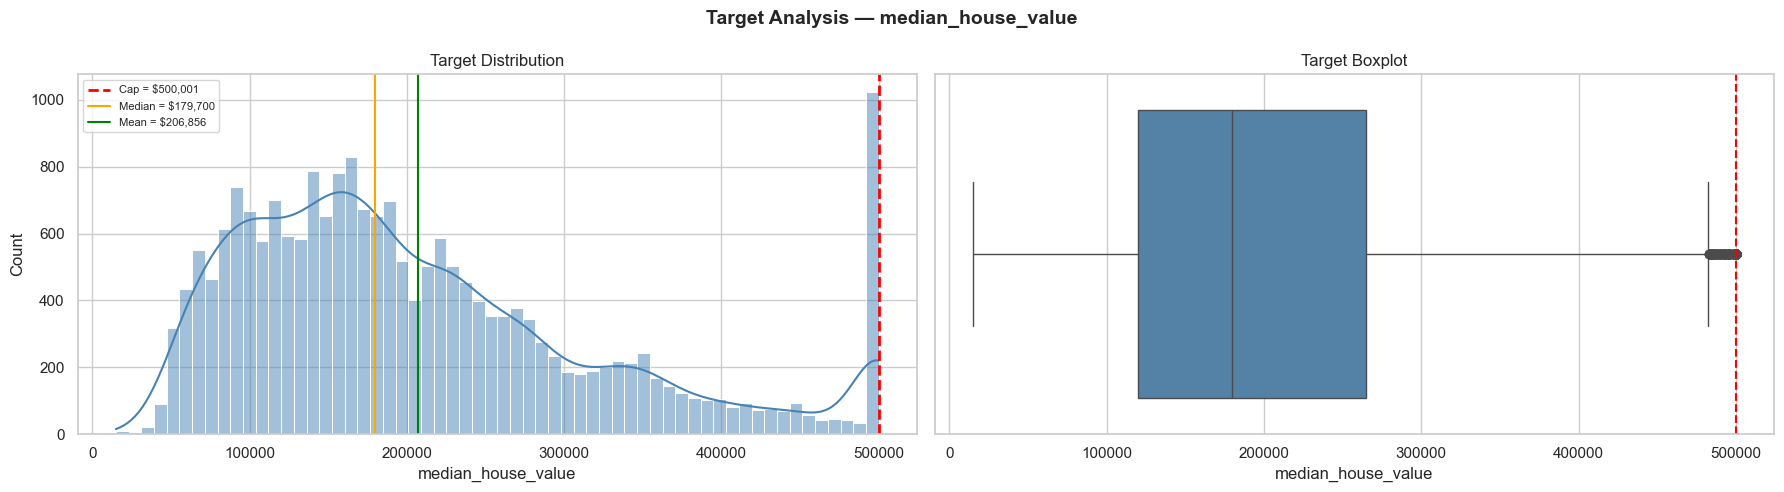

Capped rows (≥ $500,001): 965 (4.7%)
Skewness (original): 0.98


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

y_raw = df["median_house_value"]

sns.histplot(y_raw, bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(500_001, color="red", linestyle="--", linewidth=2, label="Cap = $500,001")
axes[0].axvline(y_raw.median(), color="orange", linestyle="-", linewidth=1.5, label=f"Median = ${y_raw.median():,.0f}")
axes[0].axvline(y_raw.mean(), color="green", linestyle="-", linewidth=1.5, label=f"Mean = ${y_raw.mean():,.0f}")
axes[0].set_title("Target Distribution")
axes[0].legend(fontsize=8)

sns.boxplot(x=y_raw, ax=axes[1], color="steelblue")
axes[1].axvline(500_001, color="red", linestyle="--")
axes[1].set_title("Target Boxplot")


plt.suptitle("Target Analysis — median_house_value", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./images/1_target_analysis.png",dpi=300, bbox_inches="tight")
plt.show()

cap_count = (y_raw >= 500_001).sum()
cap_pct = cap_count / len(y_raw) * 100
print(f"Capped rows (≥ $500,001): {cap_count} ({cap_pct:.1f}%)")
print(f"Skewness (original): {y_raw.skew():.2f}")


**Insights:**

1. **Lệch phải (right-skewed, skewness ~1.0)**: Đây là đặc trưng kinh điển của phân phối giá bất động sản. Lý do: đa số người dân có thu nhập trung bình → mua nhà phân khúc phổ thông, nhưng có một nhóm nhỏ giàu có → đẩy đuôi phải lên.

2. **Mean > Median (~\$207k vs ~\$180k)**: Chênh lệch ~\$27k cho thấy nhóm nhà đắt kéo trung bình lên. Trong bối cảnh California 1990, \$180k là giá trung vị — phản ánh giá nhà đã cao hơn nhiều so với trung bình.

3. **Tăng đột biến tại \$500,001 (~4.7%)**: Đây là dữ liệu bị cắt — cơ quan thống kê giới hạn giá tối đa để bảo vệ quyền riêng tư. Các căn nhà trị giá cao+ đều bị gom vào mốc này. → **Cân nhắc xóa** vì mô hình sẽ hiểu nhầm rằng có hàng trăm căn nhà giá đúng $500k, gây sai lệch nghiêm trọng

#### Feature: `housing_median_age`

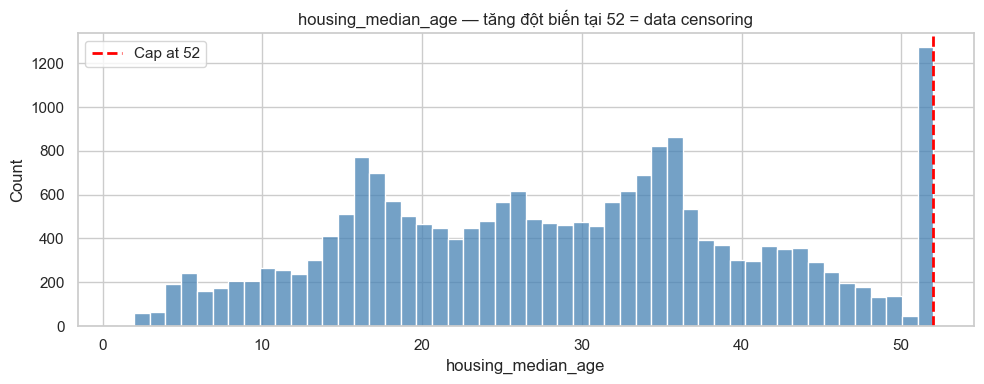

Rows with age=52: 1273 (6.2%)


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["housing_median_age"], bins=52, kde=False, ax=ax, color="steelblue")
ax.axvline(52, color="red", linestyle="--", linewidth=2, label="Cap at 52")
ax.set_title("housing_median_age — tăng đột biến tại 52 = data censoring")
ax.legend()
plt.tight_layout()
plt.savefig("./images/2_housing_median_age_distribution", dpi=300, bbox_inches="tight")
plt.show()

age_cap = (df["housing_median_age"] == 52).sum()
print(f"Rows with age=52: {age_cap} ({age_cap/len(df)*100:.1f}%)")

**Insight**: Spităng đột biến tại 52 cho thấy các nhà xây trước 1938 (52 năm trước 1990) đều bị gom chung. 
Đây không phải outlier mà là **censoring**(kiểm duyệt) — thông tin bị mất ở đuôi phải.

**Tại sao quan trọng?** Nhà cổ ở khu vực đắt tiền có giá rất khác nhà cổ ở vùng nông thôn. Khi bị cap, mô hình mất khả năng phân biệt. →Cân nhắc loại bỏ cùng với target cap.


#### Numeric Features Distribution

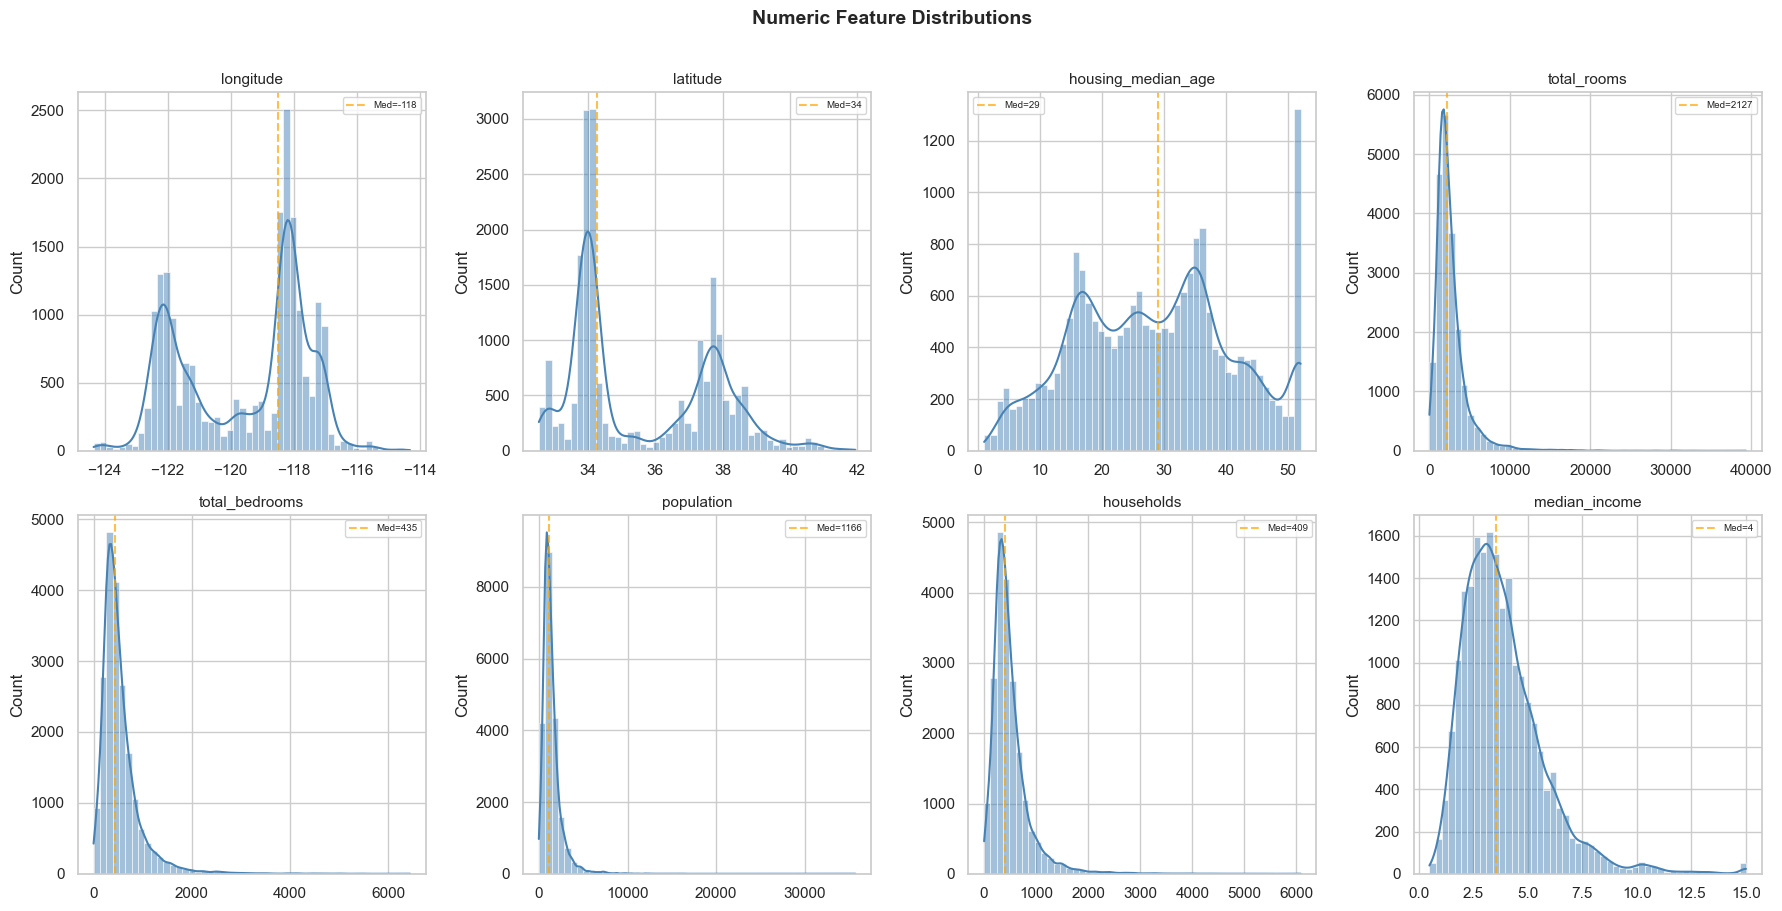

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=50, ax=ax, kde=True, color="steelblue")
    ax.axvline(df[col].median(), color="orange", linestyle="--", alpha=0.7, label=f"Med={df[col].median():.0f}")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)
    ax.set_xlabel("")
    
plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./images/3_numeric_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

**Insights chi tiết:**

1. **`longitude`/`latitude` — Bimodal**: Hai đỉnh rõ ở lat ~34 (Los Angeles) và ~37.5 (San Francisco Bay Area). Điều này phản ánh thực tế dân cư California tập trung ở 2 đô thị lớn, với Central Valley ở giữa thưa thớt hơn. → Feature này mang tính **phi tuyến** mạnh, tree models sẽ xử lý tốt hơn linear models.

2. **`total_rooms`, `total_bedrooms`, `population`, `households` — Right-skewed nặng (skew > 4)**: Đa số block groups có quy mô nhỏ, nhưng một số có giá trị rất lớn nên kéo đuôi phải dài. → **Cần log-transform** để giảm ảnh hưởng của outlier và giúp linear models hoạt động tốt.

3. **`median_income` — Gần chuẩn, đuôi phải nhẹ**: Thu nhập tuân theo phân phối log-normal. Biến này đã được Census Bureau(cục điều tra dân số Hoa Kỳ) chuẩn hóa (~đơn vị 10k USD), nên phân phối đẹp hơn. → Feature quan trọng nhất, **không cần transform thêm**.

4. **4 biến count (`total_rooms`, `total_bedrooms`, `population`, `households`) có correlation rất cao (>0.85)**: Vì tất cả đều tăng theo quy mô group-block lớn thì cái gì cũng nhiều. Raw count không nói lên chất lượng nhà, nên ta dùng ratio để chuẩn hóa theo số hộ(rooms/household, bedrooms/rooms, pop/household).

#### Categorical Feature: `ocean_proximity`

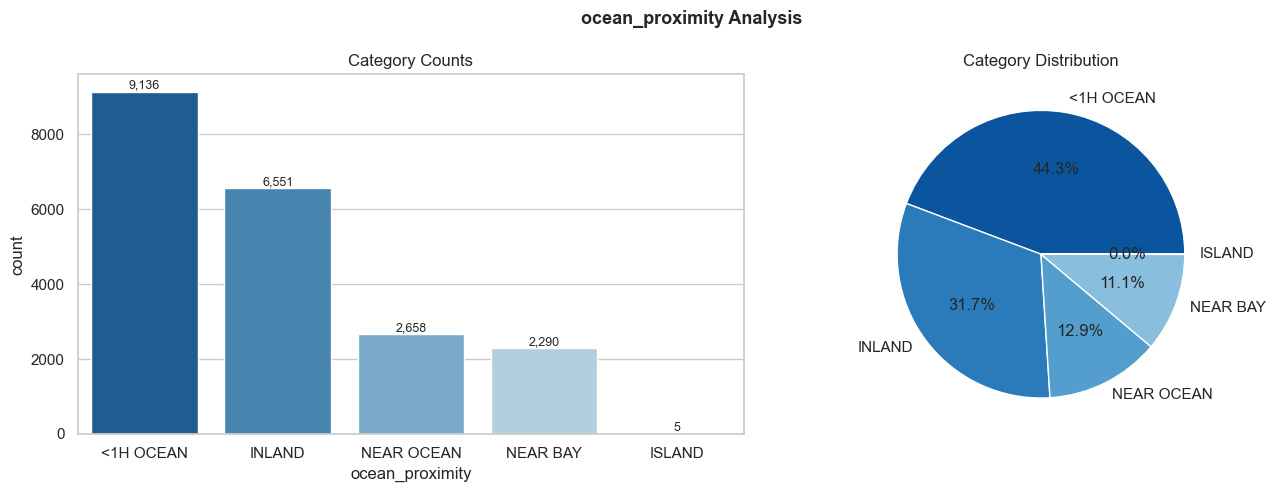

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df["ocean_proximity"].value_counts().index
sns.countplot(data=df, x="ocean_proximity", order=order, ax=axes[0], palette="Blues_r")
axes[0].set_title("Category Counts")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

pcts = df["ocean_proximity"].value_counts(normalize=True) * 100
pcts.plot(kind="pie", ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette("Blues_r"))
axes[1].set_title("Category Distribution")
axes[1].set_ylabel("")

plt.suptitle("ocean_proximity Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("./images/4_ocean_proximity_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print(df["ocean_proximity"].value_counts())

**Insights:**

- **ISLAND chỉ có 5 mẫu** — quá ít để có ý nghĩa thống kê. Mô hình sẽ overfit trên nhóm này.
- **<1H OCEAN chiếm 44%** — nhóm lớn nhất, phản ánh dân cư California tập trung ven biển.
- **INLAND chiếm 32%** 

 đề xuất giải pháp: gộp ISLAND vào NEAR OCEAN vì về mặt thực tế, đảo ven biển California có đặc điểm giá nhà tương tự vùng ven biển
  | Gộp vào | Lý do |
  |---|---|
  | NEAR OCEAN | Đảo nằm ngoài biển -> địa lý gần nhất |
  | NEAR BAY | Không hợp lý, đảo không gần vịnh |
  | <1H OCEAN | Có thể, nhưng "1 giờ lái xe" không áp dụng cho đảo |
  | INLAND | Vô lý hoàn toàn |

### 4.2 Bivariate Analysis

#### Feature vs Target — Scatter Plots

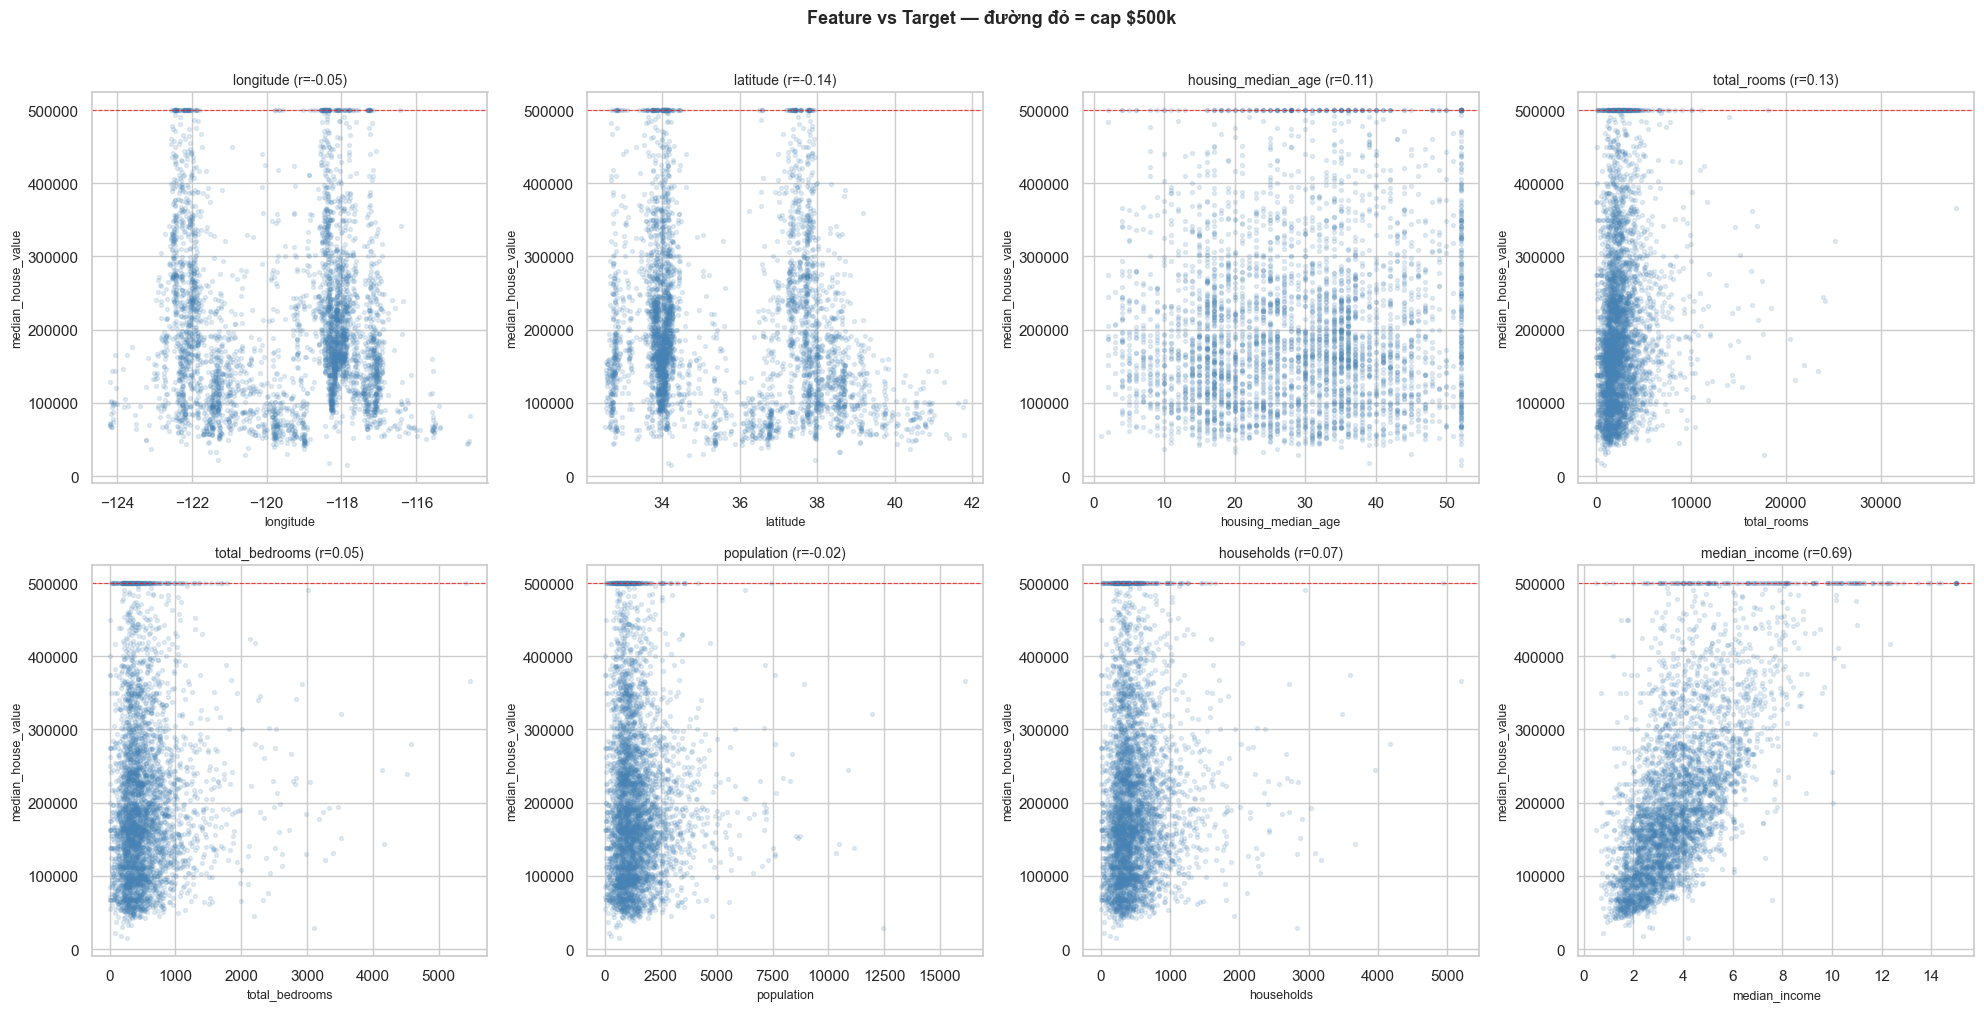

In [16]:
features = [c for c in num_cols if c != "median_house_value"]
sample = df.sample(4000, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.flatten(), features):
    ax.scatter(sample[col], sample["median_house_value"], s=8, alpha=0.15, color="steelblue")
    ax.axhline(500_001, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("median_house_value", fontsize=9)
    ax.set_title(f"{col} (r={df[col].corr(df['median_house_value']):.2f})", fontsize=10)

plt.suptitle("Feature vs Target — đường đỏ = cap $500k", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./images/5_feature_vs_target_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

**Insights quan trọng:**

1. **`median_income` — Correlation mạnh nhất (r≈0.69)**: Thu nhập cao -> mua được nhà đắt hơn. Ngân hàng thường cho vay nhiều, nên thu nhập trực tiếp giới hạn giá nhà. 

2. `total_rooms/bedrooms/population/households` — Raw count không predict được giá: Scatter plot cho thấy với cùng một giá trị total_rooms,giá nhà trải rộng từ thấp đến cao — không có xu hướng rõ ràng. Lý do: các biến này chỉ đo quy mô block group, không phản ánh chất lượng. Block group 10,000 phòng có thể là khu apartment rẻ tiền hoặc resort đắt tiền. → Cần chia cho số hộ gia đình (rooms/household) để biết mỗi hộ có bao nhiêu phòng — con số này mới thực sự nói lên chất lượng sống.

3. **`latitude` — Phi tuyến rõ rệt**: Hai "đỉnh" giá cao ở lat ~34 (LA) và ~37.5 (SF). Giữa hai vùng (Central Valley, lat ~36) giá thấp. → Linear models KHÔNG thể capture pattern này. Cần polynomial features hoặc tree-based models.

#### Correlation Analysis

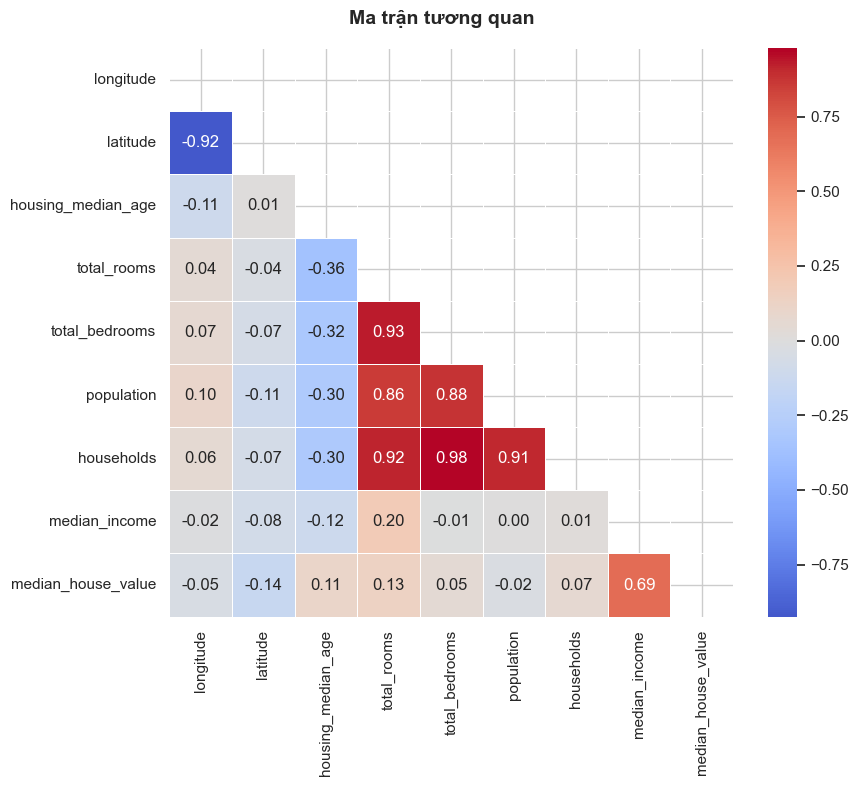

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(9, 8))

# Pearson (tuyến tính)
corr_pearson = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes, linewidths=0.5)

plt.suptitle("Ma trận tương quan", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./images/6_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ocean Proximity vs Target

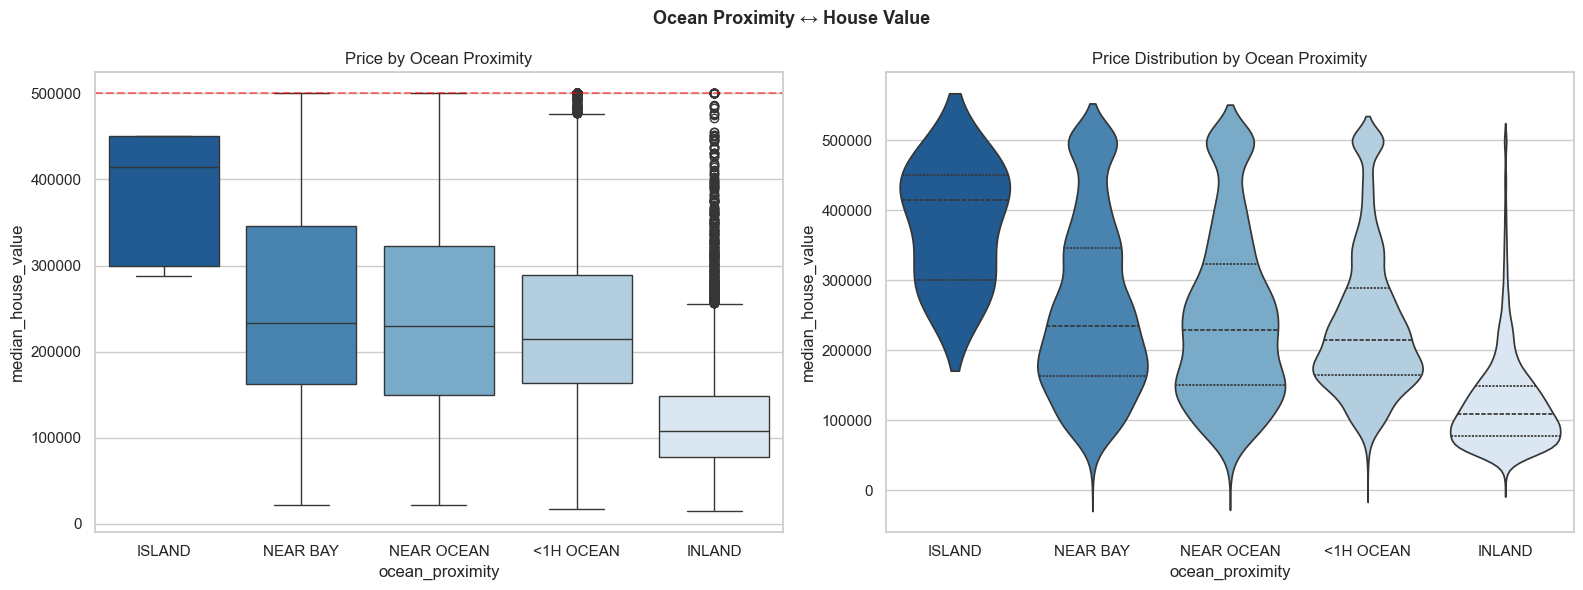

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
order = df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", order=order, ax=axes[0], palette="Blues_r")
axes[0].set_title("Price by Ocean Proximity")
axes[0].axhline(500_001, color="red", linestyle="--", alpha=0.5)

# Violin plot để thấy phân phối
sns.violinplot(data=df, x="ocean_proximity", y="median_house_value", order=order, 
               ax=axes[1], palette="Blues_r", inner="quartile")
axes[1].set_title("Price Distribution by Ocean Proximity")

plt.suptitle("Ocean Proximity ↔ House Value", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("./images/7_ocean_proximity_price_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

**Insights:**

- **ISLAND có giá cao nhất nhưng chỉ 5 mẫu** → không đáng tin.
- **NEAR BAY và NEAR OCEAN giá tương đương** — phản ánh gần biển/vịnh là yếu tố đẩy giá lên.
- **INLAND rẻ nhất rõ rệt**
- **<1H OCEAN phân tán rộng** — đây là nhóm lớn nhất (44%), gộp chung cả khu giàu lẫn khu bình dân (Compton). Violin plot phình rộng cho thấy chỉ biết "cách biển dưới 1 tiếng" chưa đủ để đoán giá — cần thêm income và vị trí cụ thể mới phân biệt được.

### 4.3 Geographic Analysis — Phân tích không gian

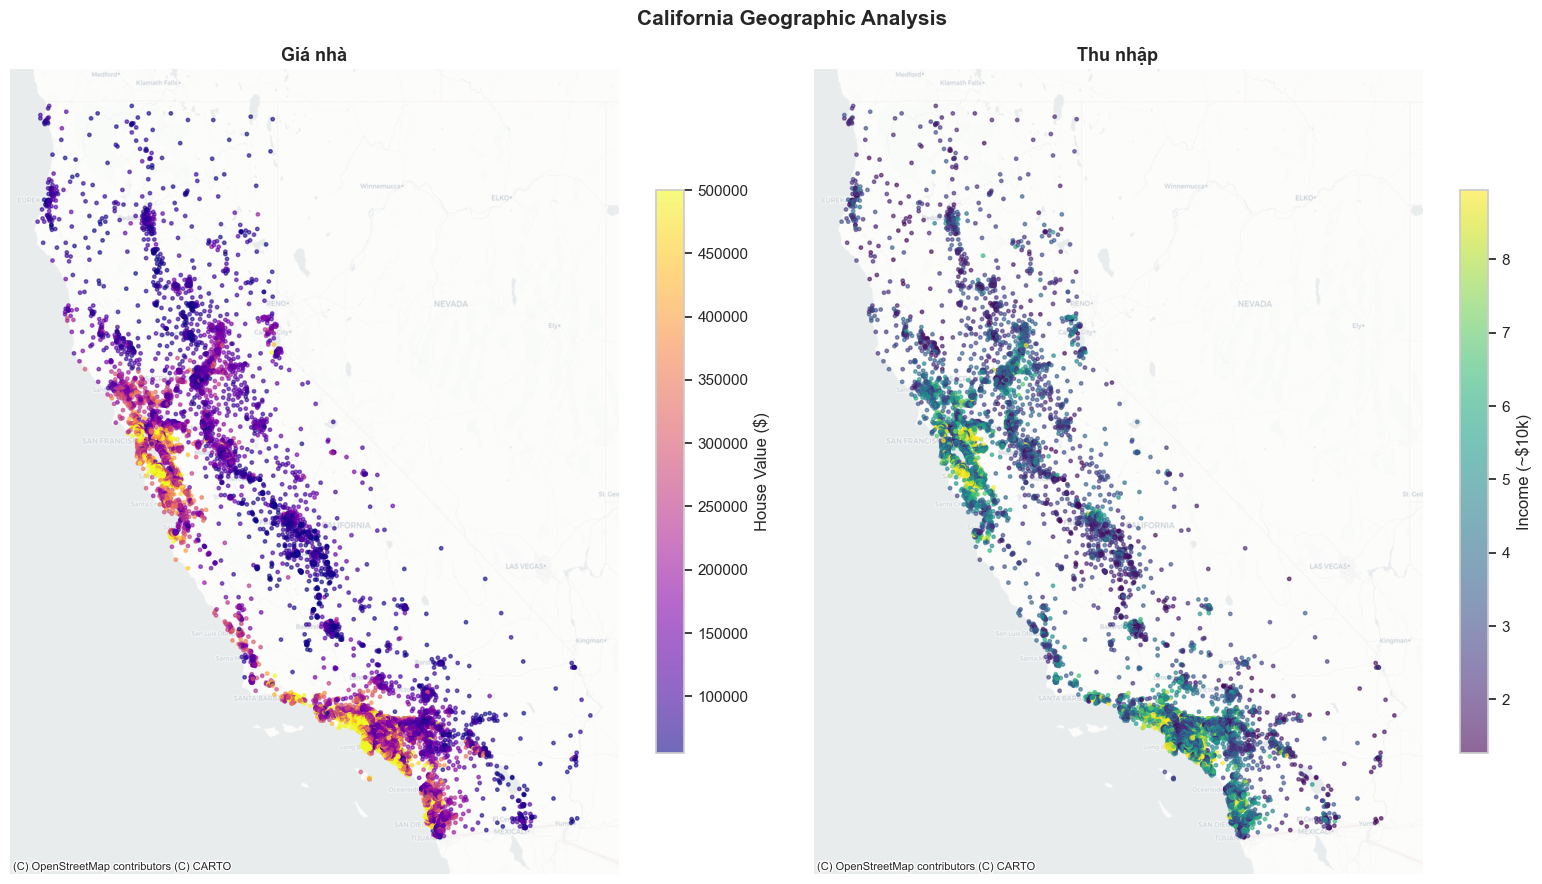

In [19]:
import contextily as ctx
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

gdf["price_to_income"] = df["median_house_value"] / (df["median_income"] * 10_000)

plot_configs = [
    ("median_house_value", "plasma",   "House Value ($)",      "Giá nhà"),
    ("median_income",      "viridis",  "Income (~$10k)",       "Thu nhập"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, (col, cmap, label, title) in zip(axes, plot_configs):
    sc = ax.scatter(gdf.geometry.x, gdf.geometry.y,
                    c=gdf[col], cmap=cmap, s=6, alpha=0.6,
                    vmin=gdf[col].quantile(0.02),
                    vmax=gdf[col].quantile(0.98))
    plt.colorbar(sc, ax=ax, label=label, shrink=0.7)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()

plt.suptitle("California Geographic Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("./images/8_california_geographic_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
  

**Insights không gian:**

Map 1 — Giá nhà

- Các điểm vàng/hồng (giá cao) tập trung dày đặc thành hai cụm lớn dọc bờ biển: Khu vực Vịnh San Francisco (phía Bắc, vĩ độ ~37.5°) và Los Angeles/Orange County (phía Nam, vĩ độ ~34°) .

- Khu vực đất liền trung tâm (Central Valley) và phía Đông Bắc có màu tím/xanh đậm, thể hiện mức giá thấp hơn đáng kể.

- Giá nhà không phân bố đồng đều trên lãnh thổ California mà suy giảm nhanh chóng khi di chuyển từ bờ biển vào sâu trong đất liền.

Map 2 — Thu nhập

- Mẫu hình phân bố gần như tương đồng hoàn toàn với Bản đồ 1.

- Các khu vực ven biển có màu xanh lục/vàng (thu nhập cao) , trong khi đất liền trung tâm có màu tím (thu nhập thấp) .

=>Insight: Điều này xác nhận median_income là đặc trưng có sức mạnh dự đoán tuyến tính lớn nhất đối với giá nhà.


Kết luận từ 2 map

Map 1 và 2 gần giống nhau → income giải thích phần lớn giá nhà

## 5. Kết luận EDA & Quyết định

### 5.1 Những vấn đề phát hiện trong dữ liệu

| Vấn đề | Chi tiết | 
|---|---|
| Giá nhà bị giới hạn tại $500,001 | Khoảng 4.7% mẫu có giá trị median_house_value = 500001. Đây là giá trị cắt ngưỡng (top-coded) do giới hạn thu thập dữ liệu, không phản ánh giá thực tế của những bất động sản cao cấp. |
| Tuổi nhà bị giới hạn tại 52 năm | Khoảng 5.1% mẫu có housing_median_age = 52. Các căn nhà trên 52 tuổi đều được gộp chung vào nhóm này, dẫn đến mất thông tin|
| Nhóm ISLAND quá ít mẫu | Chỉ có 5 mẫu thuộc nhóm ISLAND (≈ 0.024% tổng dữ liệu). Với số lượng quá nhỏ, mô hình không thể học được đặc trưng riêng biệt của khu vực đảo và dễ dẫn đến overfitting nếu giữ nguyên. |
| 4 biến đếm lệch phải nặng | Các biến total_rooms, total_bedrooms, population, households đều có hệ số bất đối xứng (skewness) > 4. Phân phối lệch mạnh có thể gây ảnh hưởng tiêu cực đến các mô hình giả định phân phối chuẩn (như hồi quy tuyến tính) hoặc nhạy cảm với thang đo. | 

### 5.2 Những phát hiện quan trọng từ EDA

| Phát hiện | Ý nghĩa |
|---|---|
| median_income có tương quan Pearson cao nhất với giá nhà (r = 0.69) | Thu nhập trung bình khu vực là yếu tố chi phối chính đến giá bất động sản. Đây là đặc trưng có sức mạnh dự báo tuyến tính lớn nhất trong tập dữ liệu. |
| `latitude/longitude` có quan hệ phi tuyến với giá | Giá cao tập trung ở hai vùng (San Francisco và Los Angeles), không tăng đều theo vĩ độ |
| Ven biển đắt hơn đất liền rõ rệt | Vị trí địa lý đóng góp vào giá ngoài yếu tố thu nhập |

### 5.3 Quyết định xử lý dữ liệu

| Quyết định | Lý do cụ thể |
|---|---|
| Loại bỏ các dòng có giá nhà ≥ $500,001 |Giá trị bị chặn trên (top‑coded) không phản ánh giá trị thực của bất động sản cao cấp. Việc loại bỏ 4.7% mẫu này giúp mô hình tránh học phải nhiễu có hệ thống và tập trung dự đoán chính xác cho phân khúc nhà ở đại chúng (< $500k). |
| Loại bỏ các dòng có tuổi nhà = 52 |Đây là giá trị kiểm duyệt (censored), gộp chung tất cả nhà xây trước 1938. Mô hình không thể phân biệt nhà 60 năm với nhà 100 năm nếu giữ lại những mẫu này.|
| Gộp nhóm ISLAND vào NEAR OCEAN |	Với chỉ 5 mẫu (0.024%), ISLAND không đủ đại diện thống kê. Xét theo đặc điểm địa lý – khí hậu và mức giá, các đảo gần bờ California tương đồng nhất với khu vực NEAR OCEAN. Quyết định này làm giảm độ thưa của biến phân loại mà không làm sai lệch bản chất dữ liệu. |
|Cân nhắc log-transform biến target | Giá nhà lệch phải → log giúp phân phối đều hơn, mô hình học chính xác hơn |
| Tạo biến tỷ lệ thay thế biến đếm thô | rooms_per_household, bedrooms_per_room, population_per_household phản ánh chất lượng sống và mật độ cư trú tốt hơn so với số tuyệt đối. Các biến này độc lập với quy mô block group, giúp mô hình tập trung vào đặc trưng có ý nghĩa kinh tế – xã hội.|

## 6. Data Preparation

In [20]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self, use_geo_cluster=True, n_geo_clusters=10,
                 cap_price=True, cap_age=True):
        self.use_geo_cluster = use_geo_cluster
        self.n_geo_clusters = n_geo_clusters
        self.cap_price = cap_price
        self.cap_age = cap_age
        self.geo_clusterer_ = None

    def fit(self, X, y=None):
        df = X.copy()

        if self.use_geo_cluster:
            coords = df[["longitude", "latitude"]].values
            self.geo_clusterer_ = KMeans(
                n_clusters=self.n_geo_clusters,
                random_state=42,
                n_init=10
            )
            self.geo_clusterer_.fit(coords)

        return self

    def transform(self, X):
        df = X.copy()

        df["ocean_proximity"] = df["ocean_proximity"].replace("ISLAND", "NEAR OCEAN")

        df["rooms_per_household"] = df["total_rooms"] / df["households"].replace(0, 1)
        df["population_per_household"] = df["population"] / df["households"].replace(0, 1)
        df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"].replace(0, 1)

        if self.use_geo_cluster and self.geo_clusterer_ is not None:
            coords = df[["longitude", "latitude"]].values
            df["geo_cluster"] = self.geo_clusterer_.predict(coords)

        return df

In [21]:
def remove_capped_detailed(df):
    df = df.copy()
    
    capped_price = df["median_house_value"] == 500_001
    capped_age   = df["housing_median_age"] == 52
    
    mask = ~(capped_price | capped_age)
    df_clean = df[mask].copy()    
    print(f"Tổng số mẫu bị loại: {len(df) - len(df_clean)}")
    return df_clean

In [22]:
df = pd.read_csv("./data/housing.csv")
df_clean = remove_capped_detailed(df)

Tổng số mẫu bị loại: 2068


In [23]:

X = df_clean.drop(["median_house_value"], axis=1)
y_original = df_clean["median_house_value"]
y_log = np.log1p(y_original)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

### Pipeline

In [24]:
NUM_LOG_COLS = [
    "rooms_per_household", 
    "population_per_household", 
    "bedrooms_per_room", 
    "population"
]
NUM_OTHER_COLS  = [
    "longitude",
    "latitude",
    "housing_median_age", 
    "median_income",
]
CAT_COLS = ["ocean_proximity","geo_cluster"]

In [25]:
log_pipeline  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

num_pipeline  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]) 

preprocessor =ColumnTransformer([
    ("log_num", log_pipeline, NUM_LOG_COLS),
    ("num", num_pipeline, NUM_OTHER_COLS),
    ("cat", OneHotEncoder(drop=None, sparse_output=False, handle_unknown="ignore"), CAT_COLS)
], remainder='drop')

feature_pipeline = Pipeline([
    ('feat_eng',    FeatureEngineering()),
    ('preprocessor', preprocessor)
])

## 7. Model Training & Hyperparameter Tuning

In [26]:
def evaluate_metrics(y_true_log, y_pred_log, name="Model"):
    y_true = np.expm1(np.asarray(y_true_log))
    y_pred = np.expm1(np.asarray(y_pred_log))
    
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    
    metrics = {"RMSE": rmse, "MAE": mae, "R2": r2}
    
    print(f"  RMSE : {rmse:>12,.0f} USD")
    print(f"  MAE  : {mae:>12,.0f} USD")
    print(f"  R²   : {r2:>12.4f}")
    
    return metrics

### 7.1 Baseline Model

In [27]:
baseline = Pipeline([('preprocess', feature_pipeline), ('model', Ridge(random_state=SEED))])
baseline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('feat_eng', ...), ('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,use_geo_cluster,True
,n_geo_clusters,10
,cap_price,True


In [28]:
baseline_y_pred = baseline.predict(X_test)
evaluate_metrics(baseline_y_pred,y_test)

  RMSE :       60,726 USD
  MAE  :       38,952 USD
  R²   :       0.4862


{'RMSE': 60726.279781320634,
 'MAE': 38952.345973972195,
 'R2': 0.48617497101820084}

### 7.2. Hyperparameter Tuning

In [29]:
svr_param_dist = {
    "model__C": loguniform(1e-2, 1e2),
    "model__epsilon": loguniform(1e-2, 1e1),
    "model__gamma":   loguniform(1e-4, 1e0),
    "model__kernel":  ["rbf", "linear"],
}
svr_pipe = Pipeline([('preprocess', feature_pipeline), ('model', SVR())])
svr_search = HalvingRandomSearchCV(
    estimator=svr_pipe,
    param_distributions=svr_param_dist,
    n_candidates=50,
    factor=3,
    min_resources=500,
    max_resources='auto',
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1
)
svr_search.fit(X_train, y_train)
best_svr = svr_search.best_estimator_

In [30]:
dt_param = {
    'model__max_depth': randint(5, 31),
    'model__min_samples_split': randint(2, 21),
    'model__min_samples_leaf': randint(1, 11)
}

dt_pipe = Pipeline([
    ('preprocess', feature_pipeline),
    ('model', DecisionTreeRegressor(random_state=SEED))
])
dt_search = HalvingRandomSearchCV(
    estimator=dt_pipe,
    param_distributions=dt_param,
    n_candidates=50,
    factor=3,
    min_resources=500,
    max_resources='auto',
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)
best_dt = dt_search.best_estimator_
print("Best DT params:", dt_search.best_params_)

Best DT params: {'model__max_depth': 9, 'model__min_samples_leaf': 10, 'model__min_samples_split': 15}


In [31]:
rf_param = {
    'model__n_estimators': randint(100, 400),
    'model__max_depth': randint(10, 30),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 5)
}
rf_pipe = Pipeline([('preprocess', feature_pipeline), ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))])
rf_search = HalvingRandomSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param,
    n_candidates=50,    
    factor=3,          
    min_resources=500,    
    max_resources='auto',
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

Best RF params: {'model__max_depth': 29, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 358}


In [32]:
knn_param = {
    'model__n_neighbors': randint(5, 20),
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

knn_pipe = Pipeline([
    ('preprocess', feature_pipeline), 
    ('model', KNeighborsRegressor())
])

knn_search = HalvingRandomSearchCV(
    knn_pipe, knn_param,
    n_candidates=50,
    factor=3,
    min_resources=500,
    max_resources='auto',
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1
)

knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
print("Best KNN params:", knn_search.best_params_)

Best KNN params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}


### 7.3 Ensemble Models

In [33]:
estimators_list = [
    ('svr', best_svr), 
    ('rf', best_rf),
    ('knn', best_knn),
    ('dt', best_dt),
    ('ridge',baseline)
]
voting_reg = VotingRegressor(estimators=estimators_list, n_jobs=-1)
voting_reg.fit(X_train, y_train)

,estimators,"[('svr', ...), ('rf', ...), ...]"
,weights,None
,n_jobs,-1
,verbose,False
,steps,"[('feat_eng', ...), ('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,use_geo_cluster,True
,n_geo_clusters,10
,cap_price,True


In [34]:
estimators_list = [
    ("svr", best_svr),
    ("rf", best_rf),
    # ("knn", best_knn),
]
stacking_reg = StackingRegressor(
    estimators=estimators_list,
    final_estimator=Ridge(random_state=SEED),
    cv=3,
    n_jobs=-1
)
stacking_reg.fit(X_train, y_train)

,estimators,"[('svr', ...), ('rf', ...)]"
,final_estimator,Ridge(random_state=42)
,cv,3
,n_jobs,-1
,passthrough,False
,verbose,0
,steps,"[('feat_eng', ...), ('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,use_geo_cluster,True


## 9. Model Evaluation

In [35]:
y_pred = best_svr.predict(X_test)
evaluate_metrics(y_test, y_pred)

  RMSE :       47,992 USD
  MAE  :       31,287 USD
  R²   :       0.7583


{'RMSE': 47991.82754313915, 'MAE': 31286.9560071056, 'R2': 0.7582584036921663}

In [36]:
y_pred = best_dt.predict(X_test)
evaluate_metrics(y_test, y_pred)

  RMSE :       52,434 USD
  MAE  :       36,039 USD
  R²   :       0.7114


{'RMSE': 52434.2069425058, 'MAE': 36038.70229327702, 'R2': 0.7114332976508875}

In [37]:
y_pred = best_rf.predict(X_test)
evaluate_metrics(y_test, y_pred)

  RMSE :       44,623 USD
  MAE  :       28,672 USD
  R²   :       0.7910


{'RMSE': 44622.83211639981,
 'MAE': 28671.602664486967,
 'R2': 0.7910073224261309}

In [38]:
y_pred = best_knn.predict(X_test)
evaluate_metrics(y_test, y_pred)

  RMSE :       50,148 USD
  MAE  :       32,946 USD
  R²   :       0.7361


{'RMSE': 50147.782993742236,
 'MAE': 32946.15054452301,
 'R2': 0.7360508397250421}

In [39]:
y_pred = voting_reg.predict(X_test)
evaluate_metrics(y_test, y_pred)

  RMSE :       47,505 USD
  MAE  :       30,899 USD
  R²   :       0.7631


{'RMSE': 47505.05333542065, 'MAE': 30899.46382626981, 'R2': 0.7631374344328715}

In [40]:
y_pred = stacking_reg.predict(X_test)
evaluate_metrics(y_test, y_pred)

  RMSE :       44,380 USD
  MAE  :       28,570 USD
  R²   :       0.7933


{'RMSE': 44379.80827168148, 'MAE': 28569.60645106646, 'R2': 0.7932775457803005}

## Lưu model và kết quả tunning

In [52]:
import json, joblib
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

In [53]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

models = {
    "baseline": baseline,
    "svr_pipeline": best_svr,
    "knn_pipeline": best_knn,
    "dt_pipeline": best_dt,
    "rf_pipeline": best_rf,
    "voting_pipeline": voting_reg,
    "stacking_pipeline": stacking_reg,
}

for name, model in models.items():
    joblib.dump(model, MODEL_DIR / f"{name}.joblib")
    print(f"Saved {name}.joblib")

Saved baseline.joblib
Saved svr_pipeline.joblib
Saved knn_pipeline.joblib
Saved dt_pipeline.joblib
Saved rf_pipeline.joblib
Saved voting_pipeline.joblib
Saved stacking_pipeline.joblib


In [ ]:
def to_serializable(obj):
    import numpy as np

    if obj is None or isinstance(obj, (bool, int, float, str)):
        return obj
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, (list, tuple)):
        return [to_serializable(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): to_serializable(v) for k, v in obj.items()}
    return str(obj)

In [ ]:
params_map = {
    "svr_pipeline": svr_search.best_params_,    
    "knn_pipeline": knn_search.best_params_,
    "dt_pipeline": dt_search.best_params_,
    "rf_pipeline": rf_search.best_params_,
}

serializable_params = to_serializable(params_map)

with open("model_params.json", "w", encoding="utf-8") as f:
    json.dump(serializable_params, f, ensure_ascii=False, indent=2)

In [56]:
results = []
for name, model in models.items():
    y_pred_log_train = model.predict(X_train)
    y_pred_log_test  = model.predict(X_test)

    y_true_train = np.expm1(y_train)
    y_true_test  = np.expm1(y_test)
    y_pred_train = np.expm1(y_pred_log_train)
    y_pred_test  = np.expm1(y_pred_log_test)

    row = {
        "model": name,
        # "params": params_map[name],  # lấy param từ map
        "train_rmse": float(np.sqrt(mean_squared_error(y_true_train, y_pred_train))),
        "test_rmse":  float(np.sqrt(mean_squared_error(y_true_test,  y_pred_test))),
        "train_mae":  float(mean_absolute_error(y_true_train, y_pred_train)),
        "test_mae":   float(mean_absolute_error(y_true_test,  y_pred_test)),
        "train_r2":   float(r2_score(y_true_train, y_pred_train)),
        "test_r2":    float(r2_score(y_true_test,  y_pred_test)),
    }
    results.append(row)

results_df = (
    pd.DataFrame(results)
    .sort_values("test_rmse")
    .reset_index(drop=True)
)
results_df.to_csv("./model_comparison.csv", index=False)
print("Saved model_comparison.csv")

display(results_df[["model","train_rmse", "test_rmse","train_mae", "test_mae","train_r2","test_r2"]].round(2))

Saved model_comparison.csv


,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,stacking_pipeline,24006.64,44379.81,15109.37,28569.61,0.94,0.79
1,rf_pipeline,17476.69,44622.83,10723.38,28671.60,0.97,0.79
2,voting_pipeline,31461.15,47505.05,20257.74,30899.46,0.89,0.76
3,svr_pipeline,42765.27,47991.83,27711.60,31286.96,0.80,0.76
4,knn_pipeline,0.00,50147.78,0.00,32946.15,1.00,0.74
5,dt_pipeline,46548.39,52434.21,31659.66,36038.70,0.76,0.71
6,baseline,57399.86,60726.28,38325.26,38952.35,0.64,0.61


In [57]:
result = pd.read_csv("./model_comparison.csv")
display(result.head())

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,stacking_pipeline,24006.636939,44379.808272,15109.370871,28569.606451,0.936567,0.793278
1,rf_pipeline,17476.690523,44622.832116,10723.383230,28671.602664,0.966382,0.791007
2,voting_pipeline,31461.149794,47505.053335,20257.735419,30899.463826,0.891056,0.763137
3,svr_pipeline,42765.269204,47991.827543,27711.601599,31286.956007,0.798703,0.758258
4,knn_pipeline,0.000000,50147.782994,0.000000,32946.150545,1.000000,0.736051


### Load Model Và Test

In [84]:
loaded_rf = joblib.load("models/stacking_pipeline.joblib")
new_house_df = pd.DataFrame(
    [[-121.9, 37.66, 18.0, 7397.0, 1137.0, 3126.0, 1115.0, 6.4994, 'INLAND']], 
    columns=['longitude', 'latitude', 'housing_median_age', 'total_rooms', 
             'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
)
pred_price = loaded_rf.predict(new_house_df)
print(f"Predicted price: ${np.exp(pred_price[0]):,.0f}") 

Predicted price: $305,044


In [77]:
df[df["ocean_proximity"] == "INLAND"].head().to_numpy()

array([[-121.92, 37.64, 46.0, 1280.0, 209.0, 512.0, 208.0, 5.1406,
        315600.0, 'INLAND'],
       [-121.9, 37.66, 18.0, 7397.0, 1137.0, 3126.0, 1115.0, 6.4994,
        323000.0, 'INLAND'],
       [-121.88, 37.68, 23.0, 2234.0, 270.0, 854.0, 286.0, 7.333,
        337200.0, 'INLAND'],
       [-121.88, 37.67, 16.0, 4070.0, 624.0, 1543.0, 577.0, 6.5214,
        311500.0, 'INLAND'],
       [-121.88, 37.67, 25.0, 2244.0, 301.0, 937.0, 324.0, 6.4524,
        296900.0, 'INLAND']], dtype=object)